In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 4")

### Section 1 : Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [5]:
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
MODELS   = ['sarima', 'prophet', 'rf', 'xgb', 'lstm']
LABELS   = ['SARIMA', 'Prophet', 'Random Forest', 'XGBoost', 'LSTM']
PALETTE  = ['#1D4ED8', '#15803D', '#B91C1C', '#B45309', '#6D28D9']
M_COLOR  = dict(zip(MODELS, PALETTE))
M_LABEL  = dict(zip(MODELS, LABELS))
print('Ready.')

Ready.


### Section 2 : Laod the Predictions

In [6]:
preds = {}
for m in MODELS:
    path = f'predictions/{m}.csv'
    if os.path.exists(path):
        preds[m] = pd.read_csv(path, parse_dates=['Date'])
        print(f'  Loaded {path}  shape={preds[m].shape}')
    else:
        print(f'  NOT FOUND: {path}  — run NB3 first')

gt = pd.read_csv('predictions/ground_truth.csv', parse_dates=['Date'])
print(f'\nGround truth shape: {gt.shape}')

  Loaded predictions/sarima.csv  shape=(428, 3)
  Loaded predictions/prophet.csv  shape=(428, 3)
  Loaded predictions/rf.csv  shape=(428, 3)
  Loaded predictions/xgb.csv  shape=(428, 3)
  Loaded predictions/lstm.csv  shape=(414, 3)

Ground truth shape: (428, 2)


### Section 3 : Metric Comparison

In [7]:
def compute_metrics(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae   = np.mean(np.abs(y_true - y_pred))
    r2    = r2_score(y_true, y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    bias  = np.mean(y_pred - y_true)
    return {'Model': name, 'RMSE': round(rmse,1), 'MAE': round(mae,1),
            'MAPE%': round(mape,2), 'sMAPE%': round(smape,2),
            'R²': round(r2,4), 'Bias': round(bias,1)}

In [8]:
records = []
for m, label in zip(MODELS, LABELS):
    if m in preds:
        p   = preds[m]
        rec = compute_metrics(p['y_true'], p['y_pred'], label)
        records.append(rec)

In [9]:
results_df = pd.DataFrame(records).set_index('Model').sort_values('RMSE')
print('=== Model Performance Comparison ===')
display(results_df.style
        .background_gradient(subset=['RMSE','MAE','MAPE%','sMAPE%'], cmap='RdYlGn_r')
        .background_gradient(subset=['R²'], cmap='RdYlGn')
        .format(precision=2))

=== Model Performance Comparison ===


,RMSE,MAE,MAPE%,sMAPE%,R²,Bias
Model,,,,,,
LSTM,353.50,260.20,7.03,7.02,0.91,4.70
Random Forest,380.40,278.80,7.59,7.14,0.90,114.70
XGBoost,416.80,317.90,8.47,7.92,0.88,232.10
Prophet,612.30,469.60,13.40,13.66,0.73,-125.70
SARIMA,1119.40,885.70,22.22,24.06,0.11,-595.70


In [10]:
best = results_df['RMSE'].idxmin()
print(f'\n Best model (RMSE): {best}')


 Best model (RMSE): LSTM


### SEction 4 : Comparison with BAR

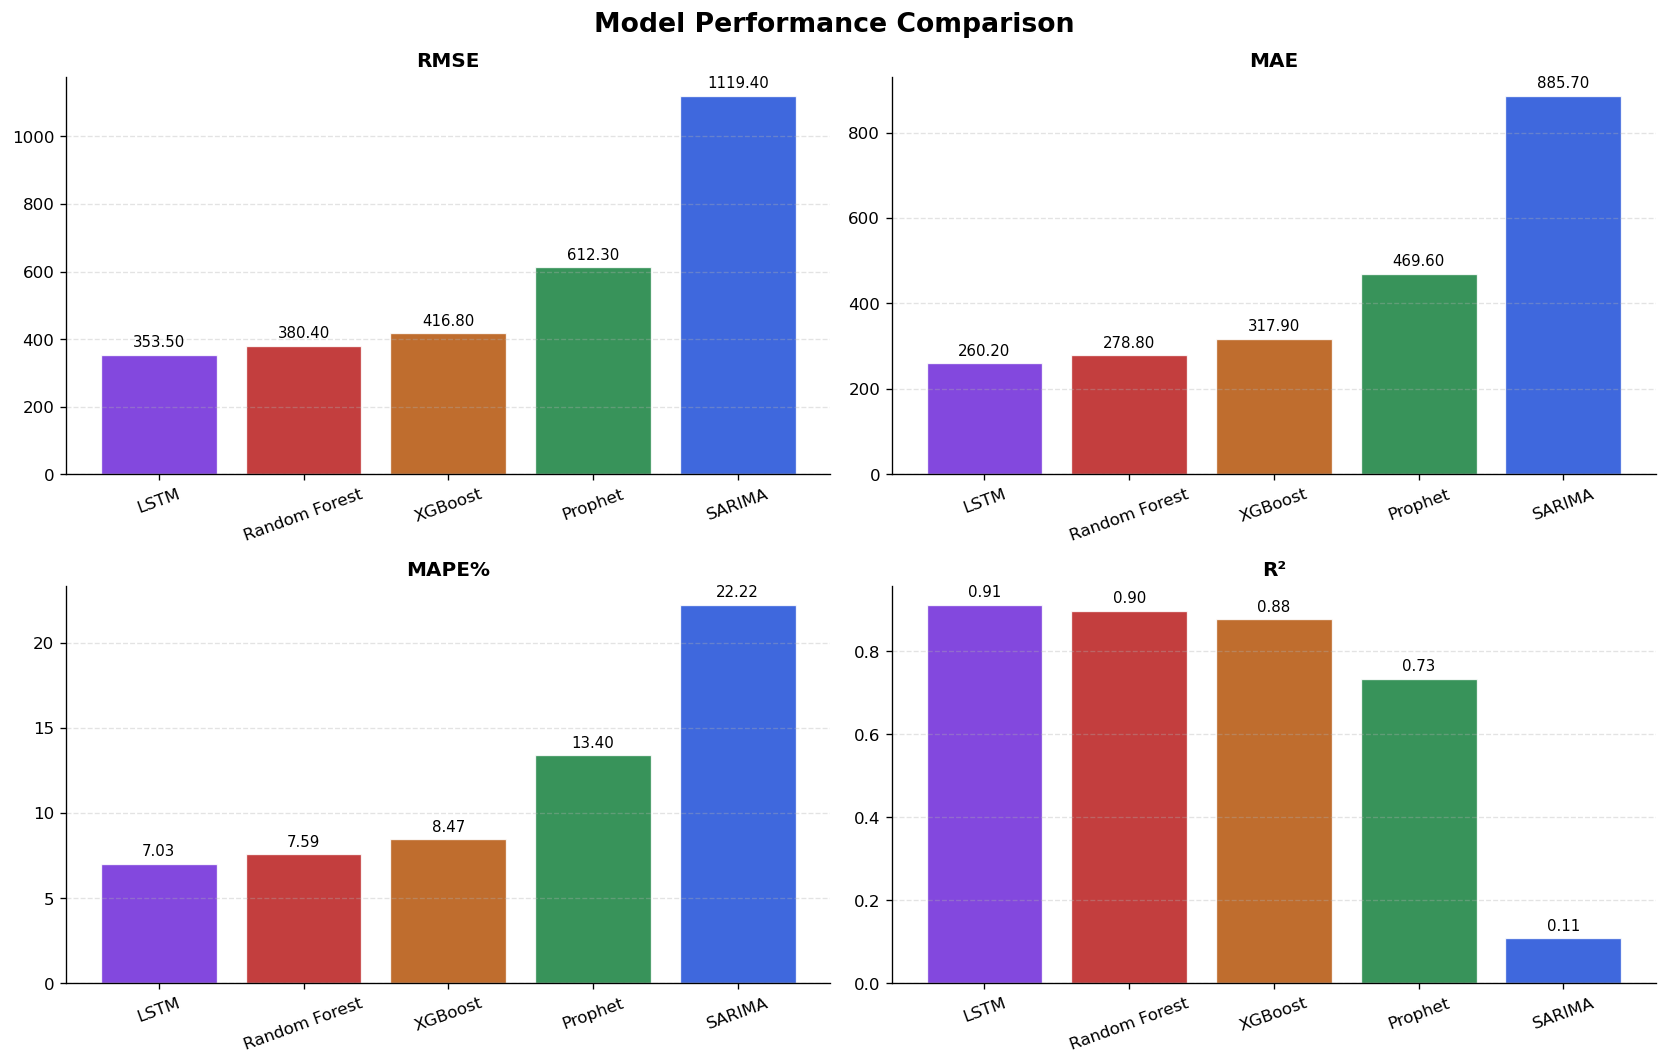

In [11]:
metrics_to_plot = ['RMSE', 'MAE', 'MAPE%', 'R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals   = results_df[metric]
    colors = [PALETTE[LABELS.index(m)] for m in vals.index]
    bars   = ax.bar(vals.index, vals.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('plots/12_metric_comparison.png', bbox_inches='tight')
plt.show()

### Section 5 : Forecast VS Actual

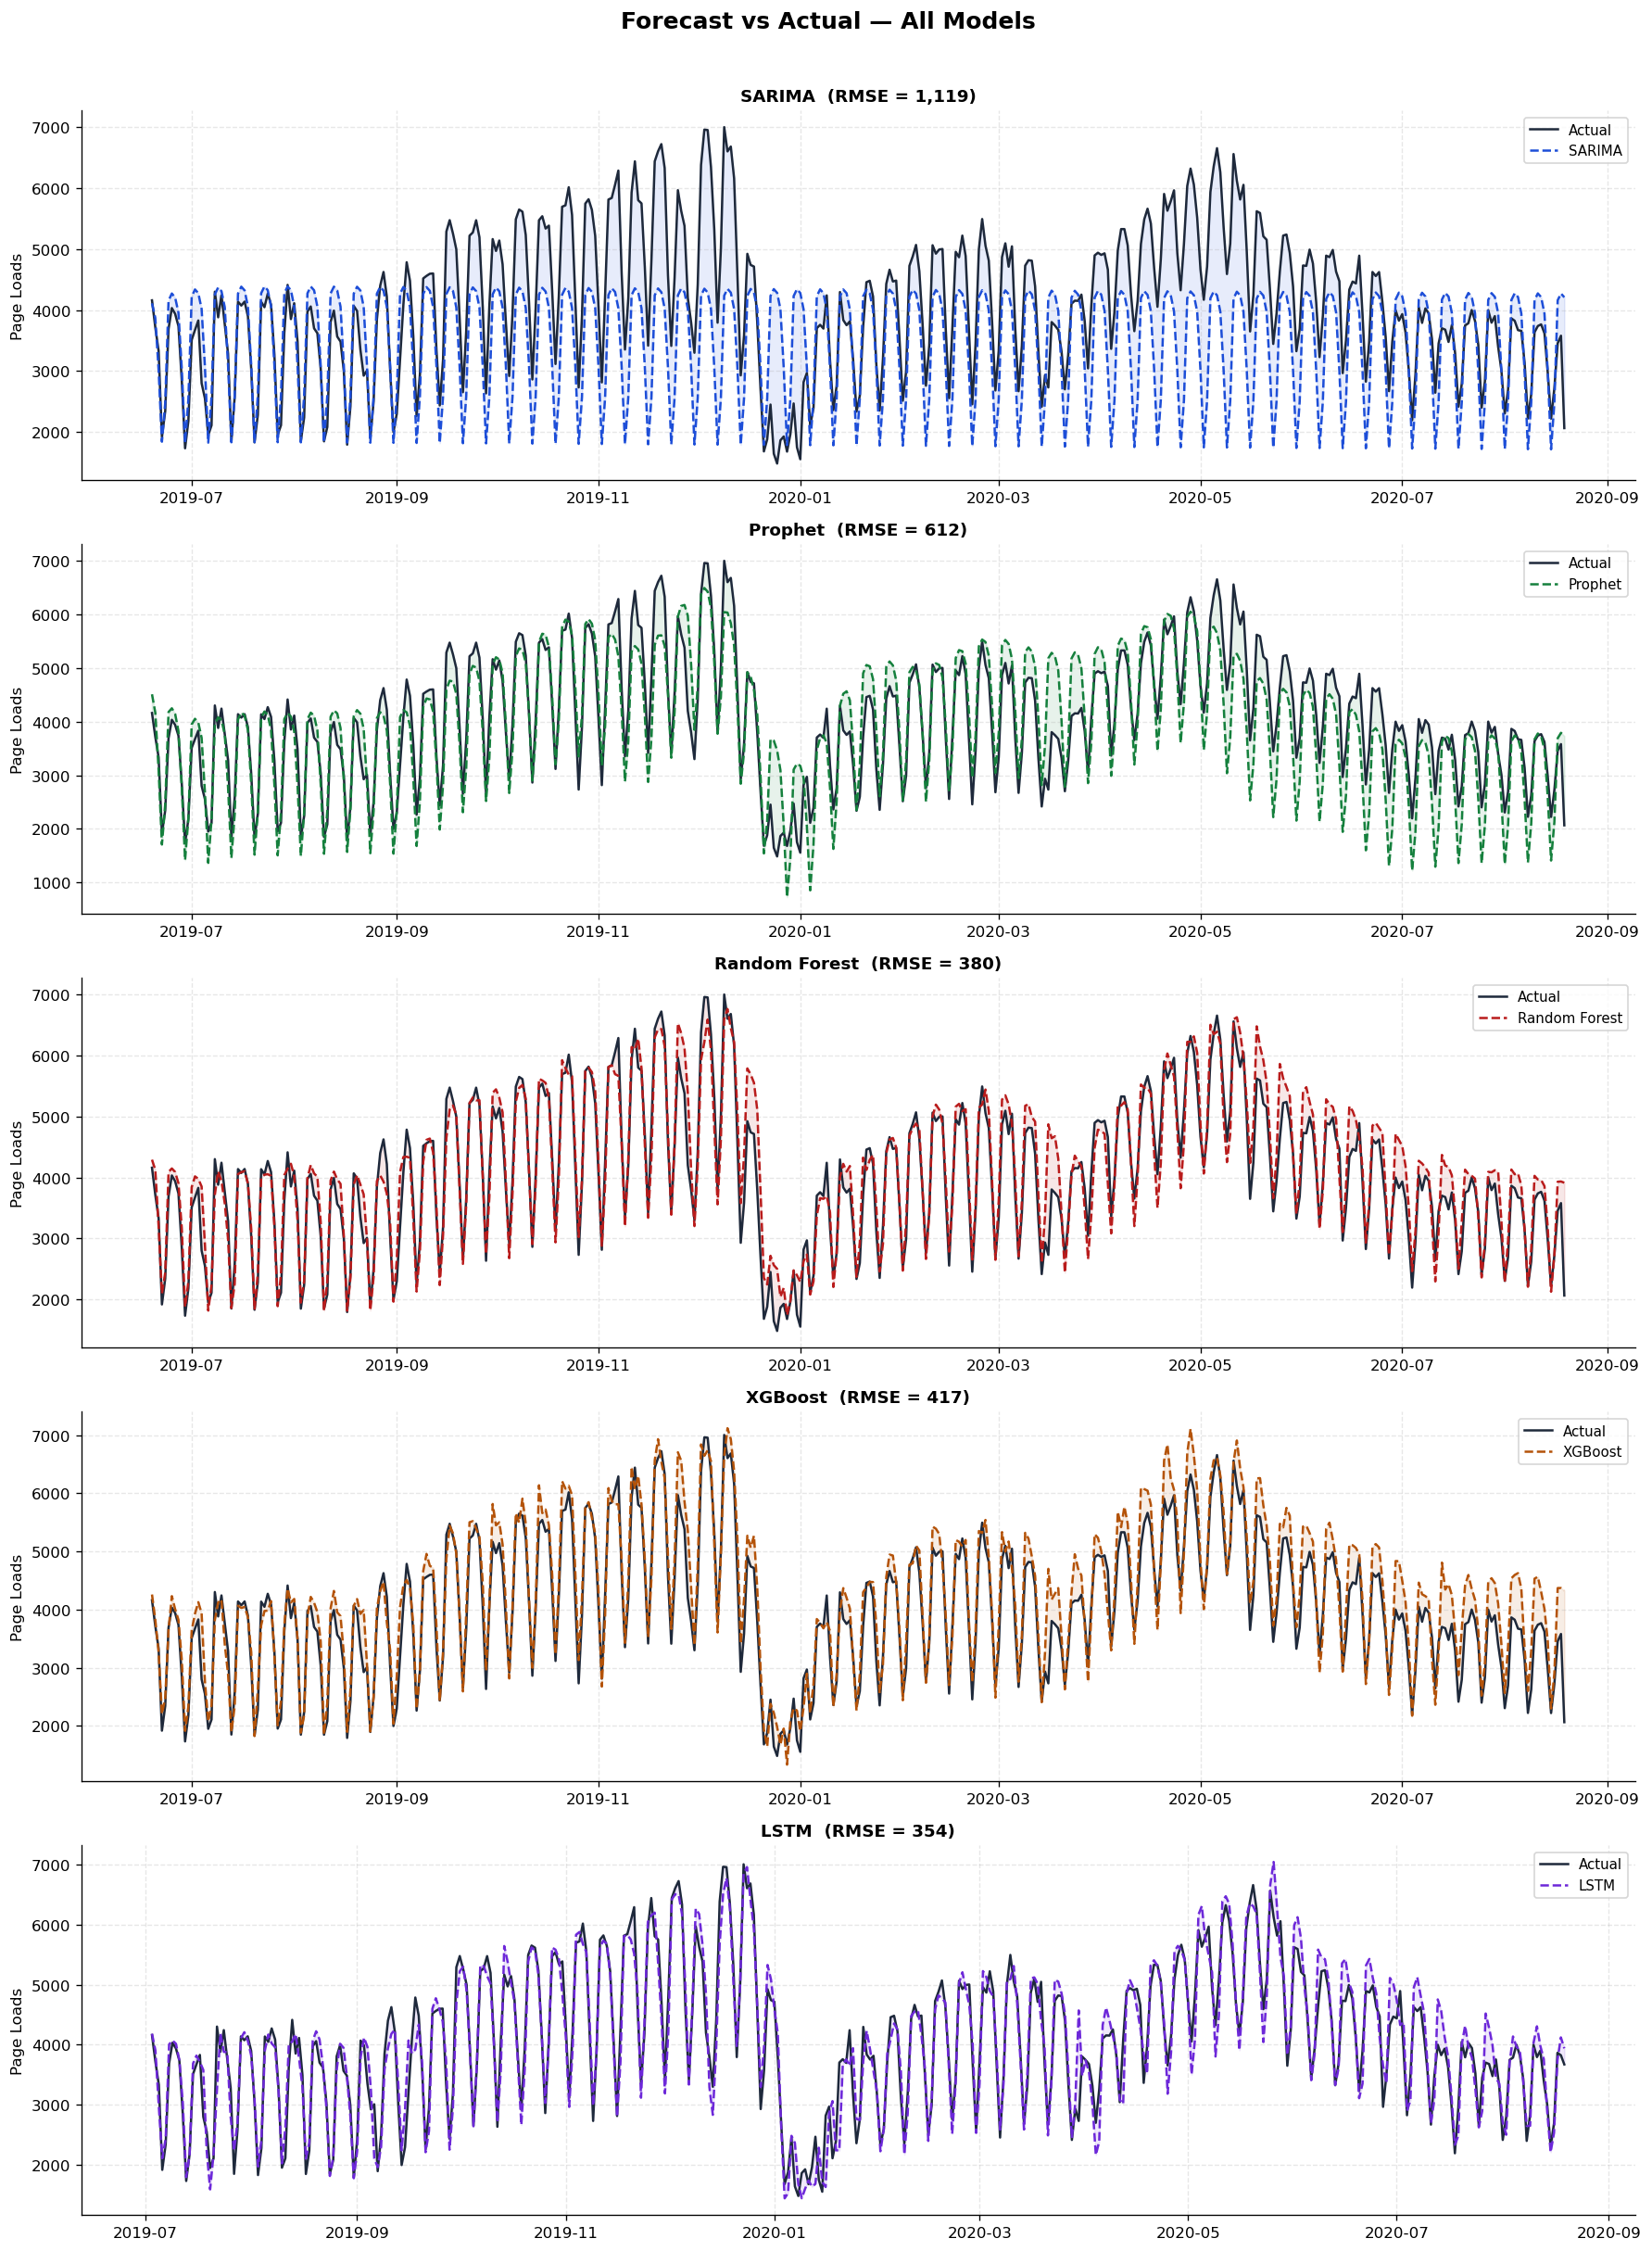

In [12]:
n_models = len(preds)
fig, axes = plt.subplots(n_models, 1, figsize=(15, 4 * n_models), sharex=False)
if n_models == 1: axes = [axes]
fig.suptitle('Forecast vs Actual — All Models', fontsize=15, fontweight='bold', y=1.01)

for ax, (m, label) in zip(axes, zip(MODELS, LABELS)):
    if m not in preds: continue
    p = preds[m]
    ax.plot(p['Date'], p['y_true'], color='#1E293B', lw=1.5, label='Actual')
    ax.plot(p['Date'], p['y_pred'], color=M_COLOR[m], lw=1.5, linestyle='--', label=label)
    ax.fill_between(p['Date'], p['y_true'], p['y_pred'],
                    alpha=0.10, color=M_COLOR[m])
    rmse_val = np.sqrt(mean_squared_error(p['y_true'], p['y_pred']))
    ax.set_title(f'{label}  (RMSE = {rmse_val:,.0f})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylabel('Page Loads')

plt.tight_layout()
plt.savefig('plots/13_forecast_panels.png', bbox_inches='tight')
plt.show()

### Section 6 : All Models Overlay

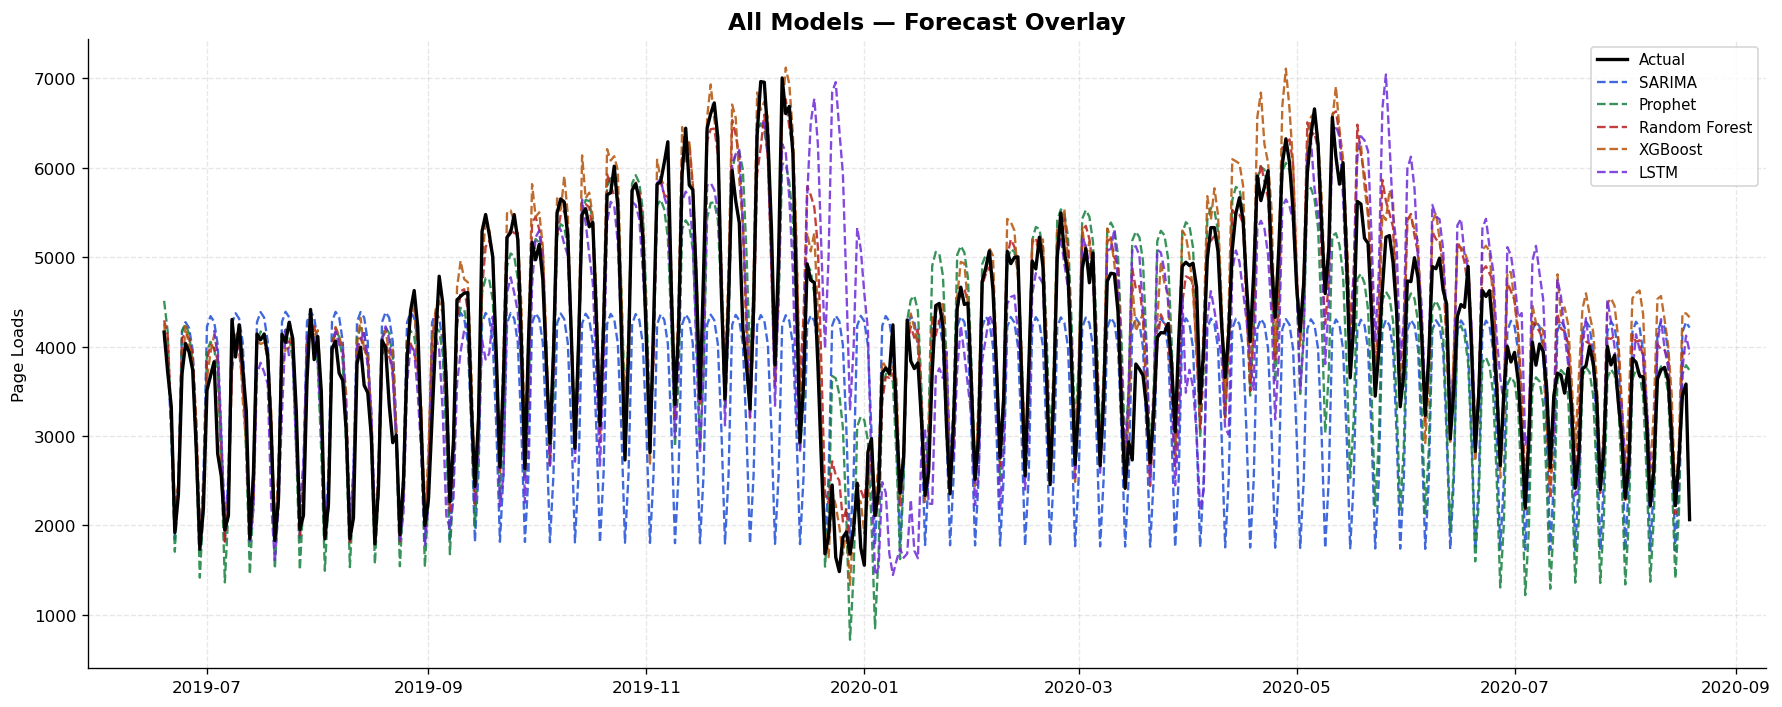

In [13]:
# Use the model with most test rows as the actual baseline for the overlay
base_m = max(preds, key=lambda m: len(preds[m]))
base_p = preds[base_m]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(base_p['Date'], base_p['y_true'], color='black', lw=2, label='Actual', zorder=5)
for m, label in zip(MODELS, LABELS):
    if m not in preds: continue
    p = preds[m]
    ax.plot(p['Date'], p['y_pred'], color=M_COLOR[m], lw=1.4,
            linestyle='--', alpha=0.85, label=label)
ax.set_title('All Models — Forecast Overlay', fontsize=14, fontweight='bold')
ax.set_ylabel('Page Loads')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14_overlay.png', bbox_inches='tight')
plt.show()

### Section 7 : Residuals Analysis

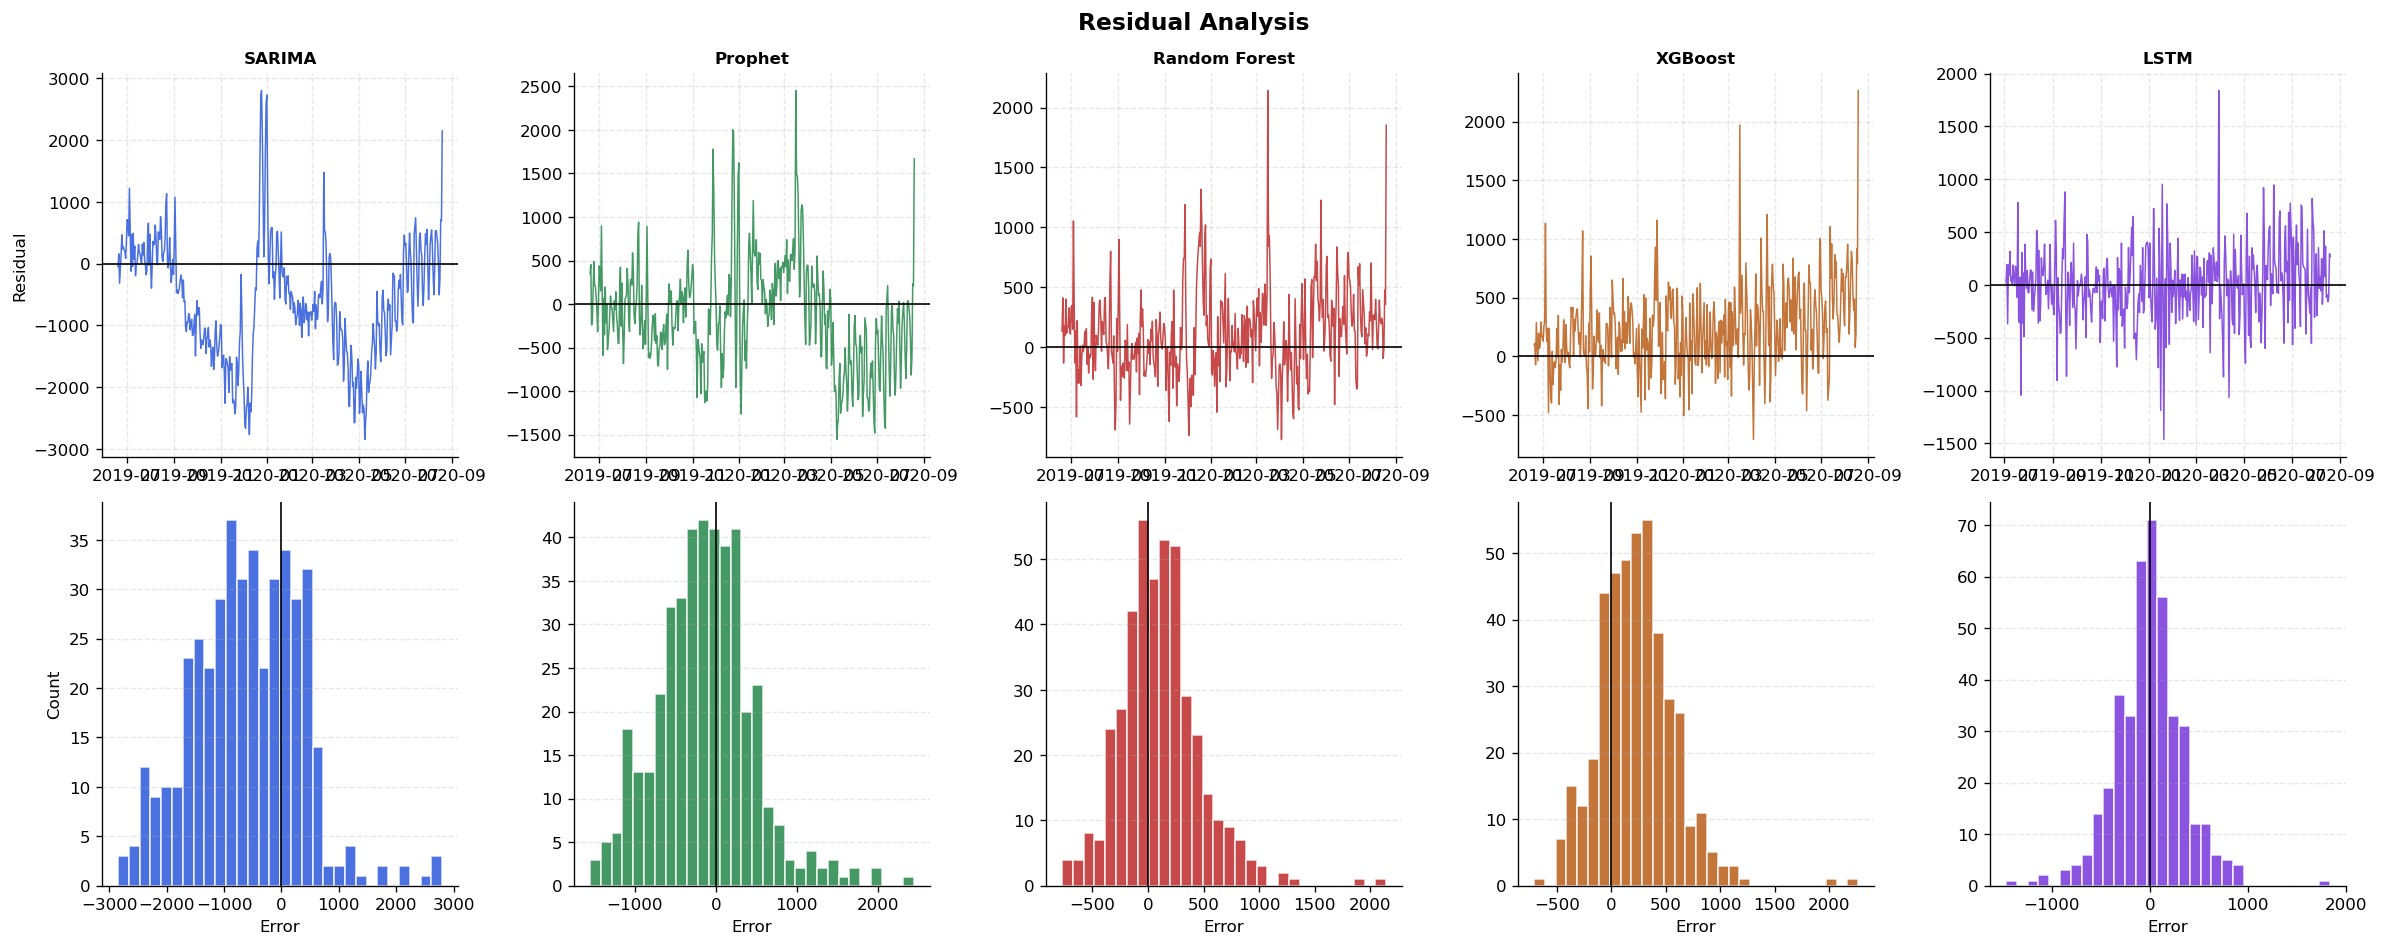

In [14]:
fig, axes = plt.subplots(2, n_models, figsize=(4*n_models, 8))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

for col, (m, label) in enumerate(zip(MODELS, LABELS)):
    if m not in preds: continue
    p        = preds[m]
    residuals = p['y_pred'].values - p['y_true'].values

    # Residuals over time
    axes[0, col].plot(p['Date'], residuals, color=M_COLOR[m], lw=0.9, alpha=0.8)
    axes[0, col].axhline(0, color='black', lw=1)
    axes[0, col].set_title(label, fontsize=10, fontweight='bold')
    axes[0, col].set_ylabel('Residual' if col == 0 else '')
    axes[0, col].grid(True, linestyle='--', alpha=0.3)

    # Histogram of residuals
    axes[1, col].hist(residuals, bins=30, color=M_COLOR[m], alpha=0.8, edgecolor='white')
    axes[1, col].axvline(0, color='black', lw=1)
    axes[1, col].set_xlabel('Error')
    axes[1, col].set_ylabel('Count' if col == 0 else '')
    axes[1, col].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/15_residuals.png', bbox_inches='tight')
plt.show()

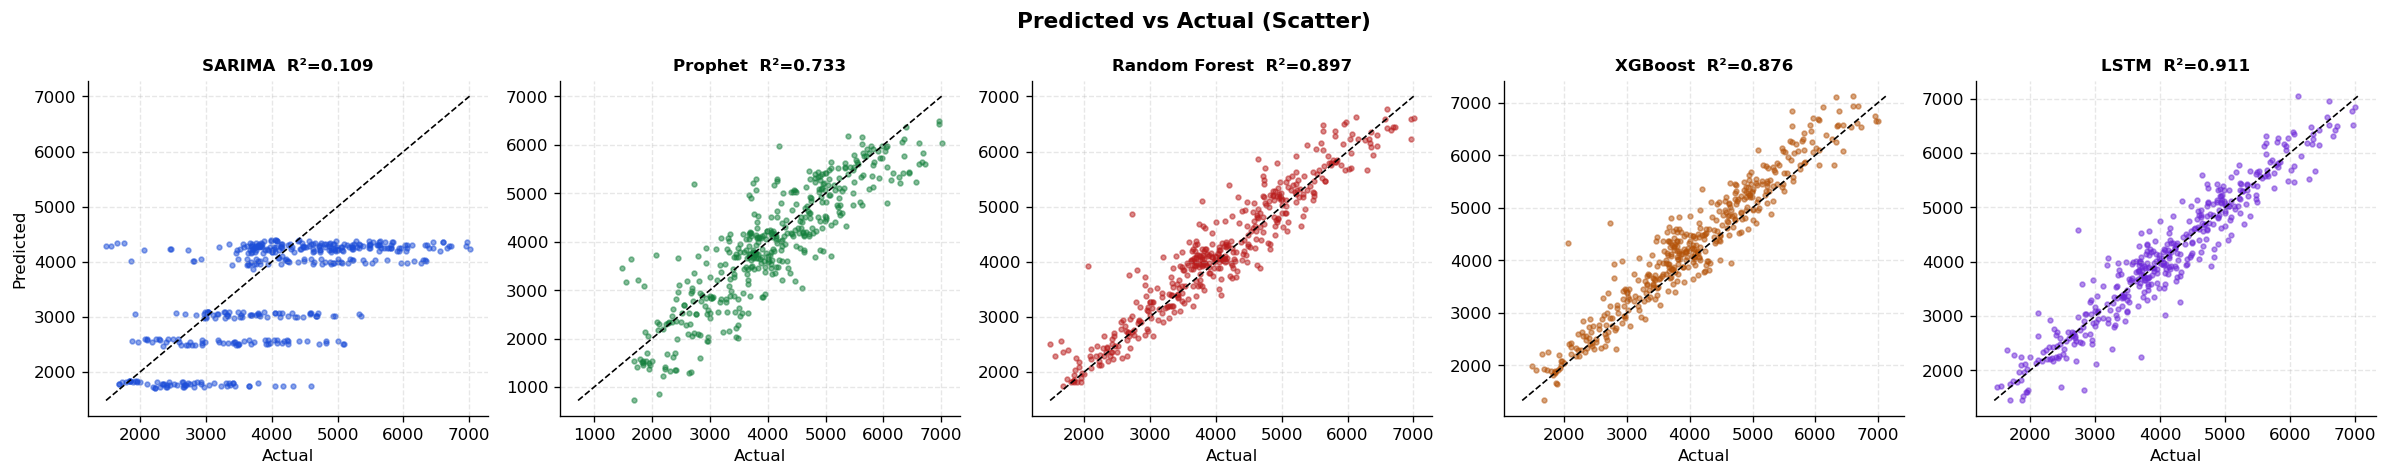

In [15]:
# Scatter: Predicted vs Actual
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1: axes = [axes]
fig.suptitle('Predicted vs Actual (Scatter)', fontsize=13, fontweight='bold')

for ax, (m, label) in zip(axes, zip(MODELS, LABELS)):
    if m not in preds: continue
    p = preds[m]
    ax.scatter(p['y_true'], p['y_pred'], s=8, alpha=0.5, color=M_COLOR[m])
    lo = min(p['y_true'].min(), p['y_pred'].min())
    hi = max(p['y_true'].max(), p['y_pred'].max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    r2 = r2_score(p['y_true'], p['y_pred'])
    ax.set_title(f'{label}  R²={r2:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted' if ax == axes[0] else '')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/16_scatter.png', bbox_inches='tight')
plt.show()

### Section 8 : ERROR Distribution

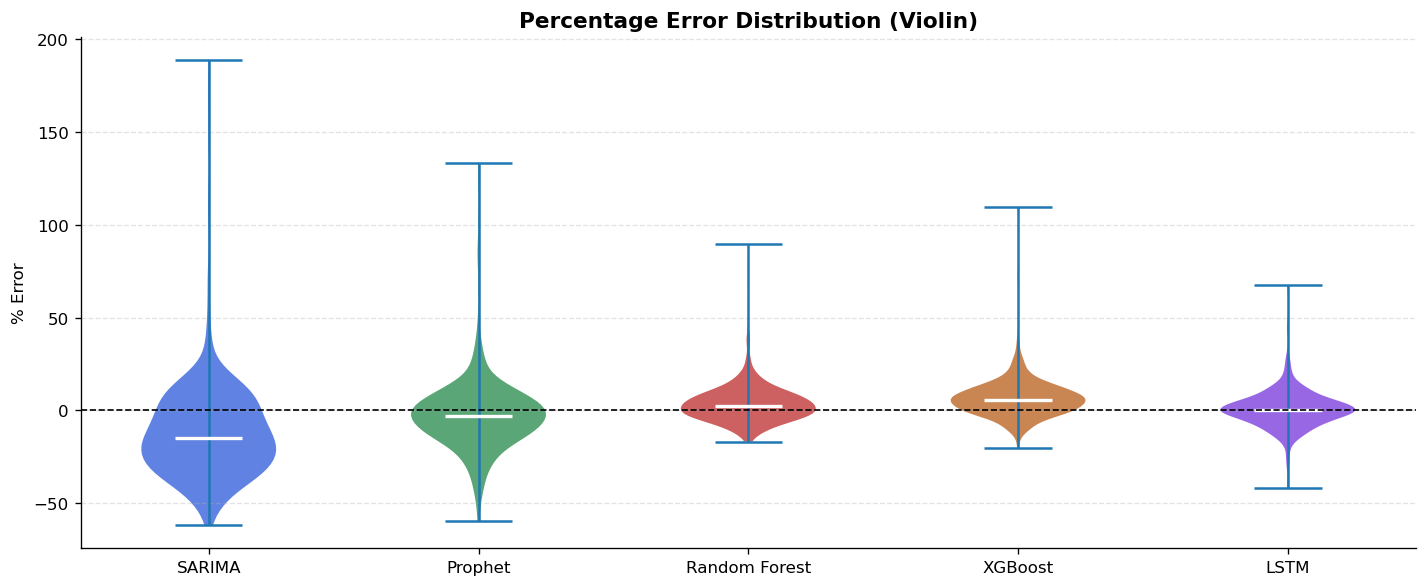

In [16]:
error_data, error_labels, error_colors = [], [], []
for m, label in zip(MODELS, LABELS):
    if m not in preds: continue
    p = preds[m]
    pct_err = (p['y_pred'].values - p['y_true'].values) / (p['y_true'].values + 1) * 100
    error_data.append(pct_err)
    error_labels.append(label)
    error_colors.append(M_COLOR[m])

fig, ax = plt.subplots(figsize=(12, 5))
vp = ax.violinplot(error_data, positions=range(len(error_data)), showmedians=True, showmeans=False)
for body, color in zip(vp['bodies'], error_colors):
    body.set_facecolor(color); body.set_alpha(0.7)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(error_labels)))
ax.set_xticklabels(error_labels)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_title('Percentage Error Distribution (Violin)', fontsize=13, fontweight='bold')
ax.set_ylabel('% Error')
ax.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/17_error_violin.png', bbox_inches='tight')
plt.show()

### Section 9 : 30 Day forecasting

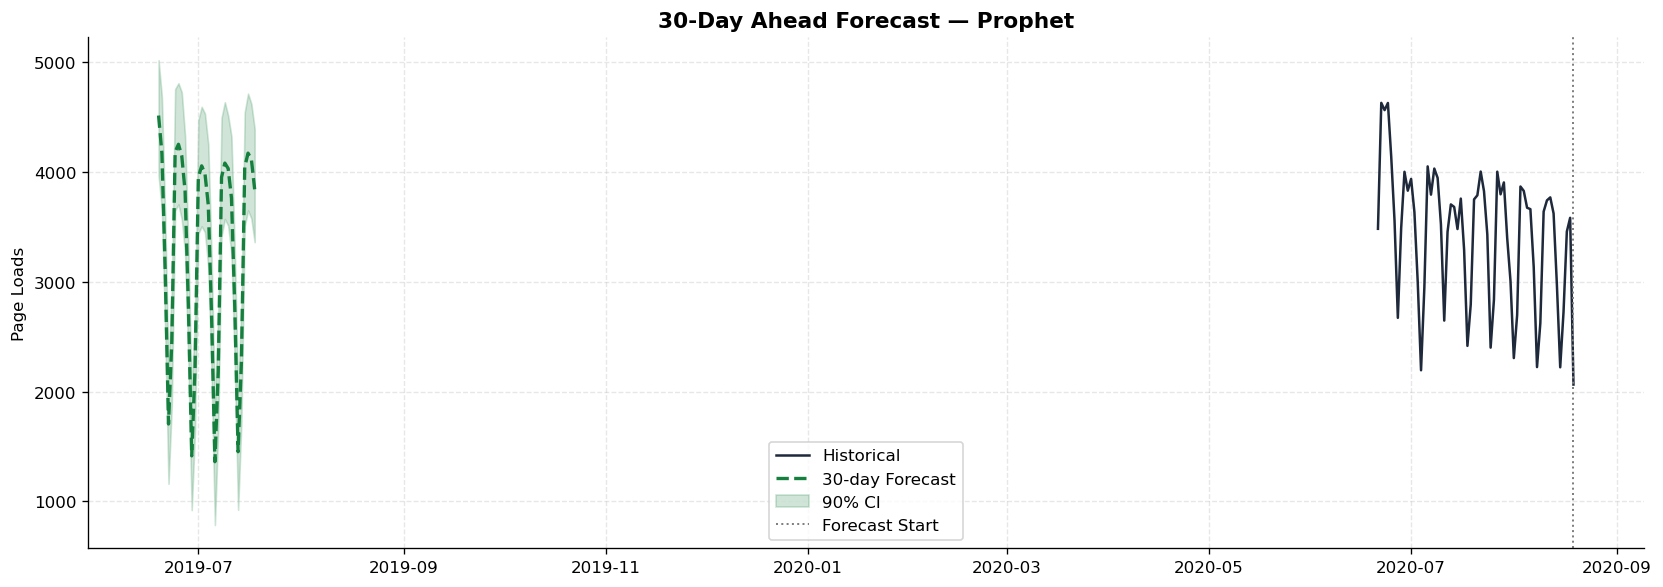


30-Day Forecast Table:


,Date,Forecast,Lower_CI,Upper_CI
0,2019-06-19,4511.766292,3965.308331,5014.875210
1,2019-06-20,4169.402838,3654.816474,4677.893459
2,2019-06-21,3093.351748,2544.320049,3596.251211
3,2019-06-22,1705.201725,1160.492849,2200.154439
4,2019-06-23,2460.586271,1887.075092,2959.348567
5,2019-06-24,4180.428647,3645.654694,4752.134512
6,2019-06-25,4250.210516,3702.874446,4805.359905
7,2019-06-26,4144.518904,3568.963648,4722.830739
8,2019-06-27,3822.670407,3259.517215,4323.996820
9,2019-06-28,2772.828281,2267.122642,3312.841086


In [17]:
if os.path.exists('models/prophet_model.pkl'):
    prophet = joblib.load('models/prophet_model.pkl')
    df_hist = pd.read_csv('data/processed_traffic.csv', parse_dates=['Date'])

    future_df = prophet.make_future_dataframe(periods=30)
    fc        = prophet.predict(future_df)
    future_fc = fc.tail(30)[['ds','yhat','yhat_lower','yhat_upper']]
    future_fc['yhat'] = np.maximum(future_fc['yhat'], 0)

    last_60 = df_hist.tail(60)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(last_60['Date'], last_60['Page_Loads'],
            color='#1E293B', lw=1.5, label='Historical')
    ax.plot(future_fc['ds'], future_fc['yhat'],
            color='#15803D', lw=2, linestyle='--', label='30-day Forecast')
    ax.fill_between(future_fc['ds'],
                    future_fc['yhat_lower'], future_fc['yhat_upper'],
                    alpha=0.2, color='#15803D', label='90% CI')
    ax.axvline(df_hist['Date'].max(), color='gray', lw=1.2, linestyle=':', label='Forecast Start')
    ax.set_title('30-Day Ahead Forecast — Prophet', fontsize=13, fontweight='bold')
    ax.set_ylabel('Page Loads')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/18_future_forecast.png', bbox_inches='tight')
    plt.show()

    print('\n30-Day Forecast Table:')
    display(future_fc.rename(columns={'ds':'Date','yhat':'Forecast',
                                      'yhat_lower':'Lower_CI','yhat_upper':'Upper_CI'})
            .reset_index(drop=True))
else:
    print('Prophet model not found. Run NB3 first.')

### Section 10 : Final Summary

In [18]:
print('=' * 62)
print('   WEBSITE TRAFFIC FORECASTING — EVALUATION SUMMARY')
print('=' * 62)
print('\n Model Rankings (by RMSE, lower is better):')
print(results_df[['RMSE','MAE','MAPE%','R²']].to_string())

print(f'\n Winner: {results_df["RMSE"].idxmin()}')

print('\n Business Insights:')
print('  1. Schedule content releases Tue–Thu (peak traffic days)')
print('  2. Scale server resources 20-30% higher on weekdays')
print('  3. Run marketing campaigns mid-week for maximum impact')
print('  4. Retrain models quarterly as traffic patterns evolve')
print('  5. Monitor MAPE weekly; alert if > 15% drift')
print('=' * 62)

   WEBSITE TRAFFIC FORECASTING — EVALUATION SUMMARY

 Model Rankings (by RMSE, lower is better):
                 RMSE    MAE  MAPE%      R²
Model                                      
LSTM            353.5  260.2   7.03  0.9113
Random Forest   380.4  278.8   7.59  0.8971
XGBoost         416.8  317.9   8.47  0.8764
Prophet         612.3  469.6  13.40  0.7333
SARIMA         1119.4  885.7  22.22  0.1086

 Winner: LSTM

 Business Insights:
  1. Schedule content releases Tue–Thu (peak traffic days)
  2. Scale server resources 20-30% higher on weekdays
  3. Run marketing campaigns mid-week for maximum impact
  4. Retrain models quarterly as traffic patterns evolve
  5. Monitor MAPE weekly; alert if > 15% drift
